# Exercise 4.2
## Linear regression
In this task we will design and train a linear model using [Keras](https://keras.io/).

### Tasks
1. Complete the implemetation of the `LinearLayer`
2. Define a meaningful objective
3. Implement gradient descent and train the linear model for 80 epochs.

In [5]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

layers = keras.layers

### Simulation of data
Let's first simulate some noisy data

In [33]:
np.random.seed(1904)
x = np.float32(np.linspace(-1, 1, 100)[:,np.newaxis])
y = np.float32(2 * x[:,0] + 0.3 * np.random.randn(100))
print("x.shape:", x.shape)
print("y.shape:", y.shape)

x.shape: (100, 1)
y.shape: (100,)


### Implement linear model

Now, we have to design a <b>linear layer</b> that maps from the input $x$ to the output $y$ using a single adaptive weight $w$:
 
$$y = w \cdot x$$

### Task 1
Complete the implementation of the `LinearLayer` by adding the linear transformation in the `call` function.

In [34]:
class LinearLayer(layers.Layer):

    def __init__(self, units=1, input_dim=1):  # when intializing the layer the weights have to be initialized
        super(LinearLayer, self).__init__()
        w_init = tf.random_normal_initializer()
        self.w = tf.Variable(initial_value=w_init(shape=(input_dim, units), dtype="float32"),trainable=True)

    def call(self, inputs):  # when calling the layer the linear transformation has to be performed
        return tf.matmul(inputs,self.w)
    


Build a model using the implemented layer.

In [35]:
model = keras.models.Sequential()
model.add(LinearLayer(units=1, input_dim=1))

In [36]:
model.build((None, 1))
print(model.summary())

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 linear_layer_3 (LinearLayer  (None, 1)                1         
 )                                                               
                                                                 
Total params: 1
Trainable params: 1
Non-trainable params: 0
_________________________________________________________________
None


### Performance before the training
Plot data and model before the training

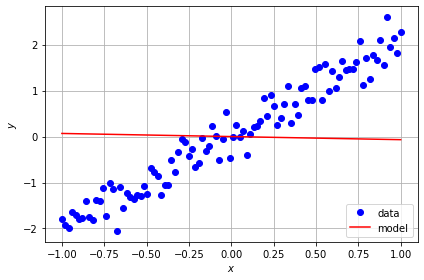

In [37]:
y_pred = model(x)

fig, ax = plt.subplots(1)
ax.plot(x, y, 'bo', label='data')
ax.plot(x, y_pred, 'r-', label='model')
ax.set(xlabel='$x$', ylabel='$y$')
ax.grid()
ax.legend(loc='lower right')
plt.tight_layout()

### Task 2: Define the objective function
Define a meaningful objective here (regression task).  
Note that you can use `tf.reduce_mean()` to average your loss estimate over the full data set (100 points).

In [42]:
def loss(x, y):
    return tf.reduce_mean((tf.squeeze(x)-tf.squeeze(y))**2)

### Task 3 - Train the model using gradient descent
'Train' the linear model for 80 epochs (or iterations) with a meaningful learning rate and implement gradient descent.  
Hint: you can access the adaptive parameters using `model.trainable_weights` and perform $w' \rightarrow w-z$ using `w.assign_sub(z)`

In [43]:
epochs = 80  # number of epochs
lr = 0.1  # learning rate
#tried lr=0.0001 or smaller: too slow 

for epoch in range(epochs):

    with tf.GradientTape() as tape:
        output = model(x, training=True)
        # Compute loss value
        loss_value = loss(tf.convert_to_tensor(y), output)
        grads = tape.gradient(loss_value, model.trainable_weights)
        #from https://www.tensorflow.org/guide/autodiff
        #[dl_dw, dl_db] = tape.gradient(loss, [w, b])
        
        for weight, grad in zip(model.trainable_weights, grads):
            weight.assign_sub(lr*grad)
            #from https://www.tensorflow.org/guide/basic_training_loops
            #model.w.assign_sub(learning_rate * dw)

        print("Current loss at epoch %d: %.4f" % (epoch, float(loss_value)))

Current loss at epoch 0: 1.5754
Current loss at epoch 1: 1.3788
Current loss at epoch 2: 1.2081
Current loss at epoch 3: 1.0597
Current loss at epoch 4: 0.9309
Current loss at epoch 5: 0.8190
Current loss at epoch 6: 0.7218
Current loss at epoch 7: 0.6373
Current loss at epoch 8: 0.5640
Current loss at epoch 9: 0.5003
Current loss at epoch 10: 0.4449
Current loss at epoch 11: 0.3969
Current loss at epoch 12: 0.3551
Current loss at epoch 13: 0.3189
Current loss at epoch 14: 0.2874
Current loss at epoch 15: 0.2600
Current loss at epoch 16: 0.2363
Current loss at epoch 17: 0.2156
Current loss at epoch 18: 0.1977
Current loss at epoch 19: 0.1821
Current loss at epoch 20: 0.1686
Current loss at epoch 21: 0.1568
Current loss at epoch 22: 0.1466
Current loss at epoch 23: 0.1378
Current loss at epoch 24: 0.1301
Current loss at epoch 25: 0.1234
Current loss at epoch 26: 0.1176
Current loss at epoch 27: 0.1125
Current loss at epoch 28: 0.1082
Current loss at epoch 29: 0.1043
Current loss at epoc

### Performance of the fitted model
Plot data and model after the training

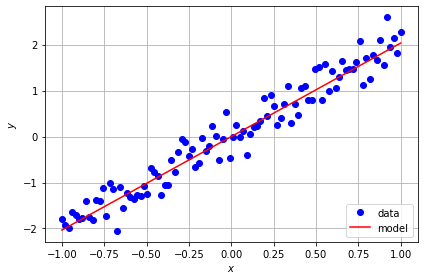

In [44]:
fig, ax = plt.subplots(1)

y_pred = model(x)

ax.plot(x, y, 'bo', label='data')
ax.plot(x, y_pred, 'r-', label='model')
ax.set(xlabel='$x$', ylabel='$y$')
ax.grid()
ax.legend(loc='lower right')
plt.tight_layout()